In [1]:
from sqlalchemy import create_engine
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import StratifiedKFold
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import roc_auc_score
from scipy.stats import ks_2samp
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.calibration import calibration_curve
from sklearn.metrics import roc_curve
from sklearn.calibration import CalibratedClassifierCV

In [2]:
database='postgres'
user='postgres'
password='postgres'
host='localhost'
port='5433'

engine = create_engine(f"postgresql://{user}:{password}@{host}:{port}/{database}")
query = "select * from fct__german_credit_wide"

data = pd.read_sql(query, engine)
data.drop(columns='id',inplace=True)

In [3]:
def plot_corr(df):
    corr = df.drop(columns='risk').corr()
    
    plt.figure(figsize=(8,6))
    sns.heatmap(corr, annot=False, cmap="coolwarm", fmt=".2f", linewidths=0.5)
    plt.title("Correlation Heatmap")
    plt.show()

def scale(df):
    numeric = list(df.select_dtypes(include=['number']).columns)
    scaler = StandardScaler()
    numeric_scaled = scaler.fit_transform(df[numeric])
    df_scaled = df.copy()
    df_scaled[numeric] = numeric_scaled
    return df_scaled

def one_hot_encode(df):
    non_numeric = list(df.select_dtypes(exclude=['number']).columns)
    df_encoded = pd.get_dummies(df, columns=non_numeric, drop_first=True).astype(int)
    print('Non-numeric columns:')
    for _ in non_numeric:
        print('   ',_)
    print('Encoded data shape: ',df_encoded.shape)
    return df_encoded

In [4]:
data.head()

,risk,age,age_numeric_group,age_group,sex,duration_months,credit_amount,log_credit_amount,credit_exposure,credit_per_age_year,...,has_no_checking_info,saving_accounts,checking_account,job_skill_level,housing_stability_score,stable_profile_flag,high_risk_profile_flag,housing,purpose,purpose_risk_group
0,1,67,3,senior,male,6,1169,7.063904,7014,17,...,0,NaN,little,2,2,1,0,own,radio/TV,consumer
1,0,22,0,young_adult,female,48,5951,8.691315,285648,270,...,0,little,moderate,2,2,1,0,own,radio/TV,consumer
2,1,49,2,mature_adult,male,12,2096,7.647786,25152,42,...,1,little,NaN,1,2,0,0,own,education,investment
3,1,45,2,mature_adult,male,42,7882,8.972337,331044,175,...,0,little,little,2,1,0,0,free,furniture/equipment,asset_backed
4,0,53,2,mature_adult,male,24,4870,8.490849,116880,91,...,0,little,little,2,1,0,0,free,car,asset_backed


In [5]:
df = data[[
    'risk',
    'age_numeric_group',
    'sex',
    'loan_term_numeric_tier',
    'saving_accounts',
    'checking_account',
    'has_no_savings_info',
    'has_no_checking_info',
    'job_skill_level',
    'housing',
    'purpose_risk_group'
]].copy()

#ordered_cols = ['age_group', 'loan_term_tier']
label_cols = ['sex', 'saving_accounts', 'checking_account', 'housing', 'purpose_risk_group']

#age_order = ['young_adult', 'adult', 'mature_adult', 'senior']
#loan_term_order = ['short', 'medium', 'long']

#oe = OrdinalEncoder(categories=[age_order, loan_term_order])
#df[ordered_cols] = oe.fit_transform(df[ordered_cols])

df = pd.get_dummies(df, columns=label_cols, drop_first=False).astype(int)

X = df.copy()
X.drop(columns='risk',inplace=True)
y = df['risk']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [7]:
tree = DecisionTreeClassifier(
    max_depth=3,
    min_samples_leaf=15,
    class_weight='balanced',
    criterion='gini',
    random_state=42
)

tree.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",15
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current n

In [8]:
y_prob = tree.predict_proba(X_test)[:,1]

In [9]:
auc = roc_auc_score(y_test, y_prob)

good = y_prob[y_test == 0]
bad  = y_prob[y_test == 1]
ks_stat, _ = ks_2samp(good, bad)

print(f"AUC: {auc:.3f}")
print(f"KS:  {ks_stat:.3f}")

AUC: 0.748
KS:  0.386


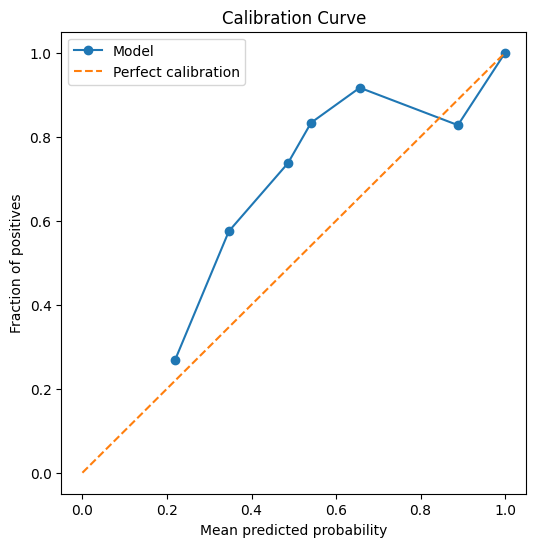

In [10]:
fraction_of_positives, mean_predicted_value = calibration_curve(
    y_test, y_prob, n_bins=10
)

plt.figure(figsize=(6,6))
plt.plot(mean_predicted_value, fraction_of_positives, marker='o', label='Model')
plt.plot([0,1], [0,1], linestyle='--', label='Perfect calibration')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Calibration Curve')
plt.legend()
plt.show()

In [11]:
calibrated_model = CalibratedClassifierCV(tree, method='sigmoid')
calibrated_model.fit(X_train, y_train)

y_prob_cal = calibrated_model.predict_proba(X_test)[:, 1]

auc_cal = roc_auc_score(y_test, y_prob_cal)
good_cal = y_prob_cal[y_test == 0]
bad_cal  = y_prob_cal[y_test == 1]
ks_cal, _ = ks_2samp(good_cal, bad_cal)

print(f"AUC calibrated: {auc_cal:.3f}")
print(f"KS calibrated:  {ks_cal:.3f}")

AUC calibrated: 0.767
KS calibrated:  0.440


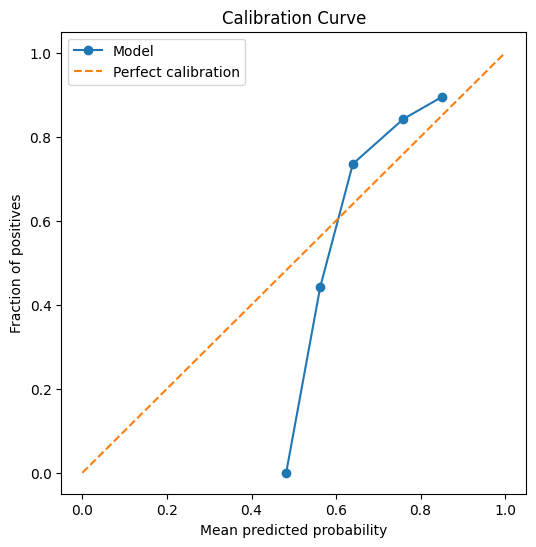

In [12]:
fraction_of_positives, mean_predicted_value = calibration_curve(
    y_test, y_prob_cal, n_bins=10
)

plt.figure(figsize=(6,6))
plt.plot(mean_predicted_value, fraction_of_positives, marker='o', label='Model')
plt.plot([0,1], [0,1], linestyle='--', label='Perfect calibration')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Calibration Curve')
plt.legend()
plt.show()

In [13]:
df = data[[
    'risk',
    'age_numeric_group',
    'sex', # Labeled
    'loan_term_numeric_tier',
    'savings_score',
    'checking_score',
    'total_liquidity_score',
    'has_no_savings_info',
    'has_no_checking_info',
    'saving_accounts',# Labeled
    'checking_account',# Labeled
    'job_skill_level',
    'housing_stability_score',
    #'stable_profile_flag',
    #'high_risk_profile_flag',
    'housing',# Labeled
    'purpose',# Labeled
    'purpose_risk_group'# Labeled
]].copy()

label_cols = ['sex', 'saving_accounts', 'checking_account', 'housing','purpose', 'purpose_risk_group']

df = pd.get_dummies(df, columns=label_cols, drop_first=False).astype(int)

X = df.copy()
X.drop(columns='risk',inplace=True)
y = df['risk']

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [15]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

In [16]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid = {
    'ccp_alpha': [0.0, 0.001, 0.005, 0.01, 0.02, 0.05],
    'max_depth': [4, 5, 6],
    'min_samples_leaf': [10, 20],
    'class_weight': ['balanced']
}

tree = DecisionTreeClassifier(random_state=42)

search = GridSearchCV(
    tree,
    param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1
)

search.fit(X_train, y_train)
best_tree = search.best_estimator_

In [17]:
y_prob = best_tree.predict_proba(X_test)[:,1]

In [18]:
auc = roc_auc_score(y_test, y_prob)

good = y_prob[y_test == 0]
bad  = y_prob[y_test == 1]
ks_stat, _ = ks_2samp(good, bad)

print(f"AUC: {auc:.3f}")
print(f"KS:  {ks_stat:.3f}")

AUC: 0.701
KS:  0.376


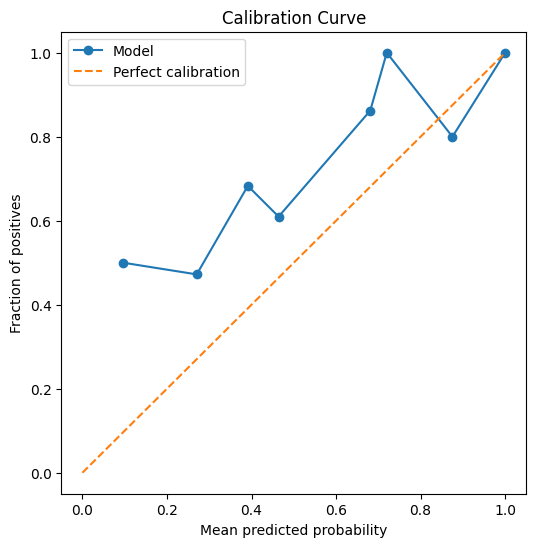

In [19]:
fraction_of_positives, mean_predicted_value = calibration_curve(
    y_test, y_prob, n_bins=10
)

plt.figure(figsize=(6,6))
plt.plot(mean_predicted_value, fraction_of_positives, marker='o', label='Model')
plt.plot([0,1], [0,1], linestyle='--', label='Perfect calibration')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Calibration Curve')
plt.legend()
plt.show()

In [20]:
calibrated_model = CalibratedClassifierCV(best_tree, method='sigmoid')
calibrated_model.fit(X_train, y_train)

y_prob_cal = calibrated_model.predict_proba(X_test)[:, 1]

# Recheck metrics
auc_cal = roc_auc_score(y_test, y_prob_cal)
good_cal = y_prob_cal[y_test == 0]
bad_cal  = y_prob_cal[y_test == 1]
ks_cal, _ = ks_2samp(good_cal, bad_cal)

print(f"AUC calibrated: {auc_cal:.3f}")
print(f"KS calibrated:  {ks_cal:.3f}")

AUC calibrated: 0.760
KS calibrated:  0.433


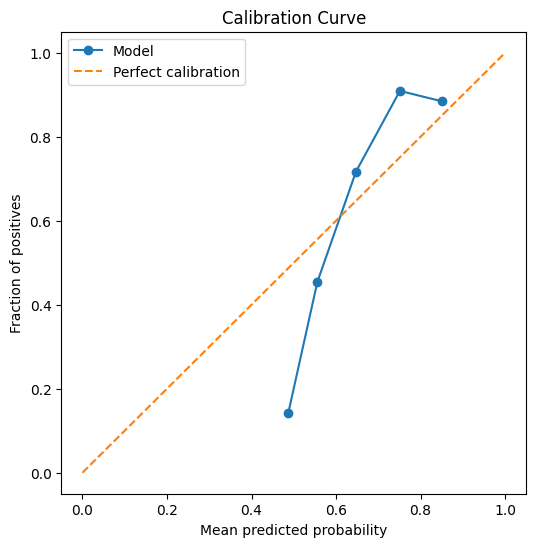

In [21]:
fraction_of_positives, mean_predicted_value = calibration_curve(
    y_test, y_prob_cal, n_bins=10
)

plt.figure(figsize=(6,6))
plt.plot(mean_predicted_value, fraction_of_positives, marker='o', label='Model')
plt.plot([0,1], [0,1], linestyle='--', label='Perfect calibration')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Calibration Curve')
plt.legend()
plt.show()

### Final: Choose best probability threshold

In [22]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob_cal)
j_scores = tpr - fpr  # Youden's J
best_threshold = thresholds[j_scores.argmax()]
print(f"Best threshold: {best_threshold:.3f}")

Best threshold: 0.608


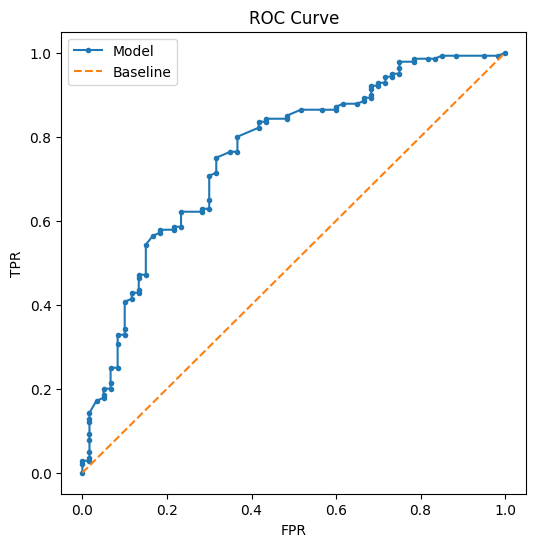

In [38]:
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, marker='.', label='Model')
plt.plot([0,1], [0,1], linestyle='--', label='Baseline')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [39]:
print(tpr[j_scores.argmax()])

0.8


In [40]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_prob_cal)

# find threshold where recall for bad class is at least 70%
# i.e. catch at least 70% of actual bad applicants
target_recall = 0.70
idx = np.where(recall >= target_recall)[0][-1]
conservative_threshold = thresholds[idx]

print(f"Threshold: {conservative_threshold:.3f}")
print(f"Precision at this threshold: {precision[idx]:.3f}")
print(f"Recall at this threshold: {recall[idx]:.3f}")

Threshold: 0.626
Precision at this threshold: 0.845
Recall at this threshold: 0.700


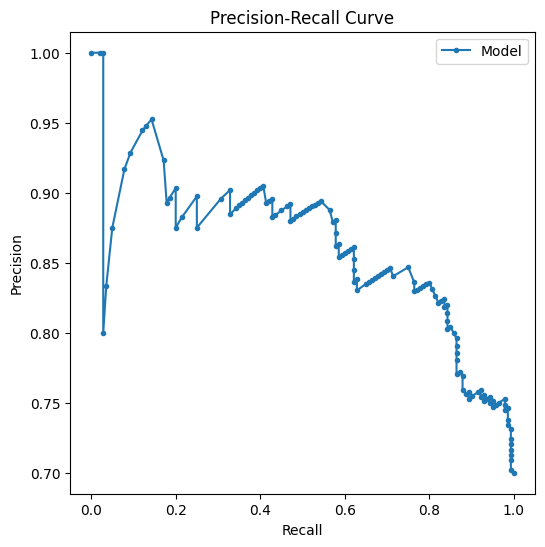

In [45]:
plt.figure(figsize=(6,6))
plt.plot(recall, precision, marker='.', label='Model')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()